In [1]:
import pandas as pd
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd

hotels = pd.read_csv('/content/drive/MyDrive/hotels_cleaned.csv')
flights = pd.read_csv('/content/drive/MyDrive/flights.csv')
users = pd.read_csv('/content/drive/MyDrive/users_cleaned.csv')
sessions = pd.read_csv('/content/drive/MyDrive/sessions_cleaned.csv')

Mounted at /content/drive


In [3]:
sessions

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,430722-1359c68b732c4e79bfbb3f12c72063dd,430722,NaN,2023-01-05 11:04:00,2023-01-05 11:07:56,True,False,0.05,NaN,False,False,32,False
1,431912-97321334a3054f458512aedeedc96514,431912,431912-1f5ebe696cc148c6a7d0234efd857a92,2023-01-05 19:50:00,2023-01-05 19:52:11,False,False,NaN,NaN,True,False,18,False
2,438839-8dadf5ca0f11475fa509f69edc178bab,438839,NaN,2023-01-05 14:19:00,2023-01-05 14:20:31,False,True,NaN,0.05,False,False,12,False
3,450164-3c35bb232f6240b8a30331dcde685071,450164,NaN,2023-01-05 06:09:00,2023-01-05 06:09:46,False,False,NaN,NaN,False,False,6,False
4,452532-f2a7363ac1954df1a502ee169dd514a4,452532,NaN,2023-01-05 14:56:00,2023-01-05 14:57:34,False,False,NaN,NaN,False,False,13,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49206,510618-15ad88eb6d794856b6f13c5800feec32,510618,NaN,2023-01-04 03:28:00,2023-01-04 03:28:09,False,False,NaN,NaN,False,False,1,False
49207,23557-9717a75d0b214ef1a77efe0092a40013,23557,NaN,2023-01-05 17:01:00,2023-01-05 17:02:32,False,False,NaN,NaN,False,False,12,False
49208,187212-1b930cb0ce5e49a9a7d6b592c8c0cf61,187212,NaN,2023-01-05 22:12:00,2023-01-05 22:12:21,False,False,NaN,NaN,False,False,3,False
49209,313724-66d14a995cca4fb0a6fbdec7c8a484e6,313724,313724-5ff715143f1d48248171238f11446d82,2023-01-05 22:29:00,2023-01-05 22:34:27,False,False,NaN,NaN,True,True,44,False


In [4]:
sessions.info()
sessions.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49211 entries, 0 to 49210
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_id              49211 non-null  object 
 1   user_id                 49211 non-null  int64  
 2   trip_id                 16702 non-null  object 
 3   session_start           49211 non-null  object 
 4   session_end             49211 non-null  object 
 5   flight_discount         49211 non-null  bool   
 6   hotel_discount          49211 non-null  bool   
 7   flight_discount_amount  8892 non-null   float64
 8   hotel_discount_amount   6815 non-null   float64
 9   flight_booked           49211 non-null  bool   
 10  hotel_booked            49211 non-null  bool   
 11  page_clicks             49211 non-null  int64  
 12  cancellation            49211 non-null  bool   
dtypes: bool(5), float64(2), int64(2), object(4)
memory usage: 3.2+ MB


,0
session_id,0
user_id,0
trip_id,32509
session_start,0
session_end,0
flight_discount,0
hotel_discount,0
flight_discount_amount,40319
hotel_discount_amount,42396
flight_booked,0


Features from User Table

In [5]:
users.columns

Index(['user_id', 'birthdate', 'gender', 'married', 'has_children',
       'home_country', 'home_city', 'home_airport', 'home_airport_lat',
       'home_airport_lon', 'sign_up_date', 'age'],
      dtype='object')

In [6]:
user_features = users[['user_id', 'gender', 'married', 'has_children','home_country', 'home_city', 'home_airport', 'age']].copy()

In [7]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age
0,94883,F,True,False,usa,kansas city,MCI,54
1,101486,F,True,True,usa,tacoma,TCM,53
2,101961,F,True,False,usa,boston,BOS,45
3,106907,F,True,True,usa,miami,TNT,47
4,118043,F,False,True,usa,los angeles,LAX,54
...,...,...,...,...,...,...,...,...
5993,780167,F,True,True,usa,los angeles,LAX,52
5994,785186,F,True,True,usa,little rock,LIT,47
5995,792549,F,False,False,usa,kansas city,MCI,48
5996,811077,F,True,True,usa,knoxville,TYS,47


Anzahl Nur Flüge

In [8]:
cancelled_trips = sessions[sessions["cancellation"]]["trip_id"]

In [9]:
valid_session = sessions[~sessions["trip_id"].isin(cancelled_trips)].copy()

In [10]:
valid_trip_ids = valid_session["trip_id"].unique()
valid_trip_ids

array([nan, '431912-1f5ebe696cc148c6a7d0234efd857a92',
       '458855-d74a01ee71694bab906b13a4a091c016', ...,
       '510580-d82f6a70f6bd4f27beb493524df2e95a',
       '510586-f4d69ffc8fdf4f289ca5d35c5c63890b',
       '313724-5ff715143f1d48248171238f11446d82'], dtype=object)

In [11]:
valid_session

,session_id,user_id,trip_id,session_start,session_end,flight_discount,hotel_discount,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
0,430722-1359c68b732c4e79bfbb3f12c72063dd,430722,NaN,2023-01-05 11:04:00,2023-01-05 11:07:56,True,False,0.05,NaN,False,False,32,False
1,431912-97321334a3054f458512aedeedc96514,431912,431912-1f5ebe696cc148c6a7d0234efd857a92,2023-01-05 19:50:00,2023-01-05 19:52:11,False,False,NaN,NaN,True,False,18,False
2,438839-8dadf5ca0f11475fa509f69edc178bab,438839,NaN,2023-01-05 14:19:00,2023-01-05 14:20:31,False,True,NaN,0.05,False,False,12,False
3,450164-3c35bb232f6240b8a30331dcde685071,450164,NaN,2023-01-05 06:09:00,2023-01-05 06:09:46,False,False,NaN,NaN,False,False,6,False
4,452532-f2a7363ac1954df1a502ee169dd514a4,452532,NaN,2023-01-05 14:56:00,2023-01-05 14:57:34,False,False,NaN,NaN,False,False,13,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49206,510618-15ad88eb6d794856b6f13c5800feec32,510618,NaN,2023-01-04 03:28:00,2023-01-04 03:28:09,False,False,NaN,NaN,False,False,1,False
49207,23557-9717a75d0b214ef1a77efe0092a40013,23557,NaN,2023-01-05 17:01:00,2023-01-05 17:02:32,False,False,NaN,NaN,False,False,12,False
49208,187212-1b930cb0ce5e49a9a7d6b592c8c0cf61,187212,NaN,2023-01-05 22:12:00,2023-01-05 22:12:21,False,False,NaN,NaN,False,False,3,False
49209,313724-66d14a995cca4fb0a6fbdec7c8a484e6,313724,313724-5ff715143f1d48248171238f11446d82,2023-01-05 22:29:00,2023-01-05 22:34:27,False,False,NaN,NaN,True,True,44,False


In [12]:
amount_only_flights_feature = valid_session[valid_session["flight_booked"]&~valid_session["hotel_booked"]].groupby("user_id")["trip_id"].count() # Feature

In [13]:
amount_only_flights_feature.rename('amount_only_flight_trips', inplace=True)

,amount_only_flight_trips
user_id,
118043,1
133058,1
204997,1
206011,1
220725,1
...,...
765745,1
767426,1
774666,1


Anzahl Nur Hotel

In [14]:
amount_only_hotel_feature = valid_session[valid_session["hotel_booked"]&~valid_session["flight_booked"]].groupby("user_id")["trip_id"].count() # Feature

In [15]:
amount_only_hotel_feature.rename('amount_only_hotel_trips', inplace=True)

,amount_only_hotel_trips
user_id,
23557,2
101486,1
118043,2
175032,1
189676,1
...,...
763129,1
763792,1
765745,1


Anzahl Hotel + Flüge

In [16]:
amount_pauschal_trip_feature = valid_session[valid_session["hotel_booked"]&valid_session["flight_booked"]].groupby("user_id")["trip_id"].count() # Feature

In [17]:
amount_pauschal_trip_feature.rename('amount_pauschal_trips', inplace=True)

,amount_pauschal_trips
user_id,
94883,2
101486,1
101961,5
118043,2
120851,1
...,...
785186,2
792549,1
796032,2


Average Seats

In [18]:
user_trip_id = sessions[["user_id", "trip_id"]].copy()

In [19]:
flights = flights.merge(user_trip_id, on="trip_id", how="left").copy()

In [20]:
flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id
0,363535-ae2567b185da4e3994607ce71f98a96b,CLT,phoenix,PHX,1,False,2023-01-13 15:00:00.000000,NaN,0,Alaska Airlines,33.535,-112.383,251.87,363535
1,549482-f5e7931dd7b6460b90b89ea0aaabfc78,YVR,san diego,SAN,1,True,2023-07-25 11:00:00.000000,2023-07-31 11:00:00.000000,1,American Airlines,32.699,-117.215,369.26,549482
2,585745-7f13ca3cb64441e08ba34a3020e7ff7b,LBB,new york,JFK,1,True,2023-07-24 07:00:00.000000,2023-07-29 07:00:00.000000,0,Allegiant Air,40.640,-73.779,407.51,585745
3,596153-eb736cf7fe6f4aaf8c1638e399111ced,YKZ,calgary,YYC,1,True,2023-07-25 15:00:00.000000,2023-07-27 15:00:00.000000,1,WestJet,51.114,-114.020,449.58,596153
4,636526-80cabddfe58c406d9ba90c77f85c66ff,LGA,los angeles,LAX,1,True,2023-07-23 13:00:00.000000,2023-07-26 13:00:00.000000,1,Air New Zealand,33.942,-118.408,691.85,636526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13723,544449-e96a99d225be4ca2862bfa16d02f94d9,LGA,chicago,MDW,2,True,2023-03-30 08:00:00.000000,2023-04-01 08:00:00.000000,0,AirTran Airways,41.786,-87.752,389.69,544449
13724,566735-978b549aa0804742883e1a10e57d6790,BOS,indianapolis,IND,1,True,2023-04-02 09:00:00.000000,2023-04-06 09:00:00.000000,1,Allegiant Air,39.717,-86.294,175.15,566735
13725,580611-b8fc699133a8430a935067cd85f68549,JFK,montreal,YUL,1,True,2023-03-31 11:00:00.000000,2023-04-05 11:00:00.000000,0,Royal Jordanian,45.517,-73.417,97.40,580611
13726,588386-233db0f627cf4aaaaeaa9a632daa5ec4,CLE,philadelphia,PHL,1,True,2023-04-04 08:00:00.000000,2023-04-06 08:00:00.000000,2,American Airlines,39.872,-75.241,106.00,588386


In [21]:
valid_flights = flights[flights["trip_id"].isin(valid_trip_ids)].copy()

In [22]:
valid_flights.shape
flights.shape

(13728, 14)

In [23]:
valid_flights["trip_id"].nunique()

12652

In [24]:
valid_flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id
0,363535-ae2567b185da4e3994607ce71f98a96b,CLT,phoenix,PHX,1,False,2023-01-13 15:00:00.000000,NaN,0,Alaska Airlines,33.535,-112.383,251.87,363535
1,549482-f5e7931dd7b6460b90b89ea0aaabfc78,YVR,san diego,SAN,1,True,2023-07-25 11:00:00.000000,2023-07-31 11:00:00.000000,1,American Airlines,32.699,-117.215,369.26,549482
2,585745-7f13ca3cb64441e08ba34a3020e7ff7b,LBB,new york,JFK,1,True,2023-07-24 07:00:00.000000,2023-07-29 07:00:00.000000,0,Allegiant Air,40.640,-73.779,407.51,585745
3,596153-eb736cf7fe6f4aaf8c1638e399111ced,YKZ,calgary,YYC,1,True,2023-07-25 15:00:00.000000,2023-07-27 15:00:00.000000,1,WestJet,51.114,-114.020,449.58,596153
4,636526-80cabddfe58c406d9ba90c77f85c66ff,LGA,los angeles,LAX,1,True,2023-07-23 13:00:00.000000,2023-07-26 13:00:00.000000,1,Air New Zealand,33.942,-118.408,691.85,636526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13723,544449-e96a99d225be4ca2862bfa16d02f94d9,LGA,chicago,MDW,2,True,2023-03-30 08:00:00.000000,2023-04-01 08:00:00.000000,0,AirTran Airways,41.786,-87.752,389.69,544449
13724,566735-978b549aa0804742883e1a10e57d6790,BOS,indianapolis,IND,1,True,2023-04-02 09:00:00.000000,2023-04-06 09:00:00.000000,1,Allegiant Air,39.717,-86.294,175.15,566735
13725,580611-b8fc699133a8430a935067cd85f68549,JFK,montreal,YUL,1,True,2023-03-31 11:00:00.000000,2023-04-05 11:00:00.000000,0,Royal Jordanian,45.517,-73.417,97.40,580611
13726,588386-233db0f627cf4aaaaeaa9a632daa5ec4,CLE,philadelphia,PHL,1,True,2023-04-04 08:00:00.000000,2023-04-06 08:00:00.000000,2,American Airlines,39.872,-75.241,106.00,588386


In [25]:
average_seat_feature = valid_flights[["seats", "user_id"]].groupby("user_id").mean() # Feature

Season analysis

In [26]:
hotels["check_in_time"]

,check_in_time
0,2023-07-19 11:00:00.000
1,2023-03-06 09:40:43.050
2,2023-05-27 14:18:53.460
3,2023-02-26 18:29:05.640
4,2023-03-05 19:18:46.935
...,...
14308,2023-07-24 14:35:10.185
14309,2023-06-08 13:02:30.300
14310,2023-07-14 13:31:41.655
14311,2023-06-10 11:00:00.000


<Axes: xlabel='check_in_month', ylabel='count'>

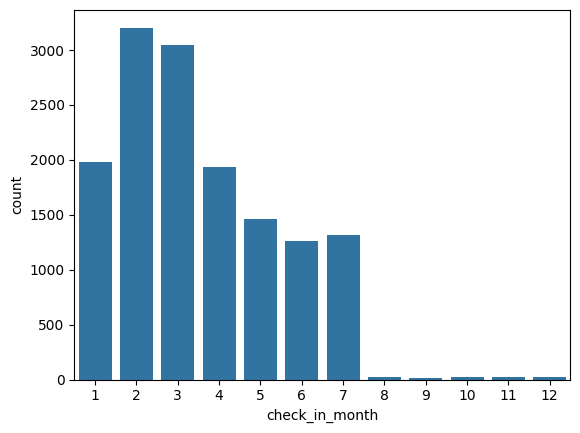

In [27]:
sns.countplot(x=hotels["check_in_month"])

Die Analyse der Check-in-Monate zeigt, dass die meisten Hotelbuchungen zwischen Januar und Juli erfolgen, mit einem Peak in Februar und März. Für die Monate August bis Dezember liegen nur wenige Beobachtungen vor, was auf eine eingeschränkte zeitliche Abdeckung oder unvollständige Daten hindeuten könnte. Diese ungleiche Verteilung sollte bei der Interpretation saisonaler Effekte berücksichtigt werden.

<Axes: xlabel='departure_time', ylabel='count'>

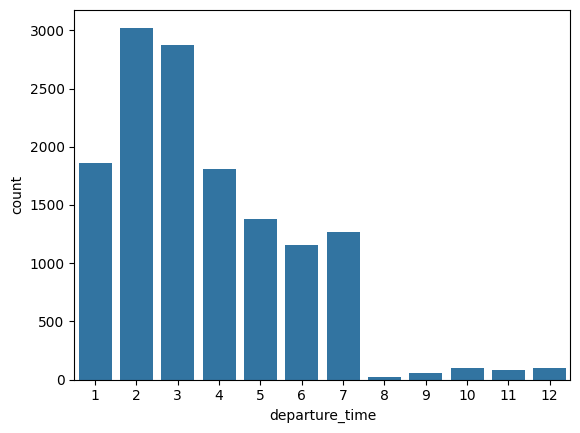

In [ ]:
sns.countplot(x=pd.to_datetime(flights["departure_time"]).dt.month)

Die meisten Flüge fanden zwischen Januar und Juli statt, mit einem Peak im Februar und März. Die Monate August bis Dezember sind kaum vertreten, wodurch saisonale Aussagen für das gesamte Jahr nur eingeschränkt möglich sind

Revenue Features

Hotel Revenue

In [28]:
hotels["nights"].value_counts()

,count
nights,
1,3236
2,2794
3,1956
4,1360
0,1208
5,888
6,669
7,470
8,386


In [29]:
hotels[hotels["nights"] == 0].head()

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,city,check_in_year,check_in_month,check_in_day,check_in_hour,check_out_year,check_out_month,check_out_day,check_out_hour,stay_length,hotel_total_cost
10,389434-cf10e38f0d464b81ace3f3be9f689833,Wyndham,0,1,2023-04-06 09:42:33.345,2023-04-06 11:00:00,107,hamilton,2023,4,6,9,2023,4,6,11,0,0
27,474384-afc75eb132ad4981b56f1a5fbde7944f,Marriott,0,1,2023-01-19 17:43:49.845,2023-01-20 11:00:00,111,houston,2023,1,19,17,2023,1,20,11,0,0
28,476693-259b98c22268467d94e6b42e57564c5f,Extended Stay,0,1,2023-03-13 14:12:01.215,2023-03-14 11:00:00,153,quebec,2023,3,13,14,2023,3,14,11,0,0
29,476714-f7d36ece6b46409cbe363123d363bd40,Banyan Tree,0,2,2023-01-15 11:44:13.425,2023-01-15 11:00:00,294,oklahoma city,2023,1,15,11,2023,1,15,11,1,0
44,498287-8304a83760cb4dbe9ccf6be20a9bed16,Fairmont,0,1,2023-03-01 09:54:01.710,2023-03-01 11:00:00,125,san diego,2023,3,1,9,2023,3,1,11,0,0


In [30]:
hotels[hotels["nights"] == 0].shape

(1208, 18)

In [31]:
hotels[["check_in_time", "check_out_time"]].dtypes

,0
check_in_time,object
check_out_time,object


In [33]:
hotels["check_in_time"] = pd.to_datetime(
    hotels["check_in_time"],
    format="mixed"
)

hotels["check_out_time"] = pd.to_datetime(
    hotels["check_out_time"],
    format="mixed"
)

In [34]:
zero_nights = hotels[hotels["nights"] == 0]

(zero_nights["check_out_time"].dt.date -  zero_nights["check_in_time"].dt.date).value_counts()

/tmp/ipykernel_16757/2460701654.py:3: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  (zero_nights["check_out_time"].dt.date -  zero_nights["check_in_time"].dt.date).value_counts()


,count
1 days,883
0 days,325


In [35]:
hotels["calculated_nights"] = (hotels["check_out_time"].dt.normalize() - hotels["check_in_time"].dt.normalize()).dt.days

In [36]:
hotels.loc[(hotels["nights"] == 0) & (hotels["calculated_nights"] == 1), "nights"] = 1

In [37]:
hotels.loc[hotels["nights"] == 0, "nights"] = 1

In [38]:
(hotels["nights"] == 0).sum()

np.int64(0)

In [39]:
hotels["total_revenue"] = hotels["nights"]*hotels["rooms"]*hotels["hotel_per_room_usd"]

In [40]:
hotels["total_revenue"].describe()

,total_revenue
count,14313.000000
mean,803.370432
std,1241.053760
min,17.000000
25%,196.000000
50%,412.000000
75%,904.000000
max,27702.000000


Der Median (412 USD) ist deutlich kleiner als der Mittelwert (803 USD) - Es gibt einige sehr teure Hotelbuchungen, die den Durchschnitt nach oben ziehen.

Die Standardabweichung ist sehr hoch. Das zeigt eine große Streuung der Hotelumsätze.

Der maximale Umsatz ist extrem hoch und sollte geprüft werden.

Fazit: Der durchschnittliche Hotelumsatz pro Buchung beträgt 803 USD, während der Median bei 412 USD liegt. Die Differenz zwischen Mittelwert und Median weist auf eine rechtsschiefe Verteilung mit einigen sehr hochpreisigen Buchungen hin. Der höchste beobachtete Umsatz beträgt 27.702 USD.

In [41]:
hotels.sort_values("total_revenue", ascending=False)[["hotel_name", "city", "nights", "rooms", "hotel_per_room_usd", "total_revenue"]].head(10)

,hotel_name,city,nights,rooms,hotel_per_room_usd,total_revenue
10493,Best Western,los angeles,27,3,342,27702
10748,InterContinental,phoenix,12,3,598,21528
2855,InterContinental,houston,19,1,1124,21356
10763,Extended Stay,san antonio,13,2,790,20540
6517,Shangri-La,dallas,9,2,1115,20070
9788,Marriott,new york,10,2,973,19460
3446,Banyan Tree,philadelphia,14,2,645,18060
13729,Marriott,el paso,16,3,375,18000
6983,NH Hotel,fort worth,31,2,279,17298
8004,Choice Hotels,montreal,18,3,295,15930


Man erkennt, dass die höchsten Umsätze meist durch eine Kombination aus:

- vielen Nächten (10–31)
- mehreren Zimmern (2–3)
- hohen Zimmerpreisen

entstehen.
Nicht nur der Preis pro Zimmer bestimmt den Umsatz

In [42]:
hotels[[ "nights", "rooms", "hotel_per_room_usd", "total_revenue"]].corr(numeric_only=True)

,nights,rooms,hotel_per_room_usd,total_revenue
nights,1.000000,0.060006,-0.012126,0.648873
rooms,0.060006,1.000000,-0.005632,0.313112
hotel_per_room_usd,-0.012126,-0.005632,1.000000,0.424994
total_revenue,0.648873,0.313112,0.424994,1.000000


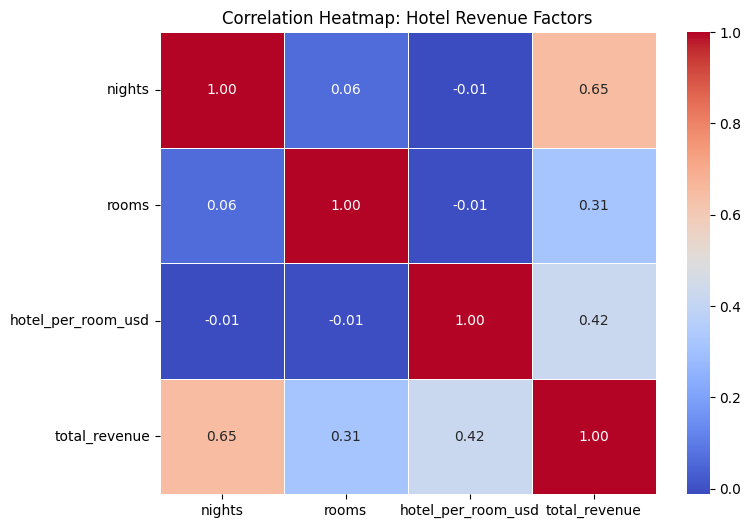

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = hotels[
    ["nights", "rooms", "hotel_per_room_usd", "total_revenue"]
].corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap: Hotel Revenue Factors")
plt.show()

Die Aufenthaltsdauer (nights) ist der wichtigste Treiber des Hotelumsatzes, gefolgt vom Zimmerpreis. Die Anzahl der Zimmer hat einen geringeren Einfluss. Zwischen den Einflussfaktoren besteht kaum Korrelation.

In [44]:
(hotels["total_revenue"] == 0).sum()

np.int64(0)

In [45]:
session_hotel_discount = sessions[["trip_id", "hotel_discount_amount"]].copy()

session_hotel_discount.loc[:, "hotel_discount_amount"] = ( 1 - session_hotel_discount["hotel_discount_amount"].fillna(0))

In [46]:
hotels = hotels.merge(session_hotel_discount, on="trip_id", how="left")

In [47]:
hotels["total_revenue_w_discount"] = hotels["total_revenue"]*hotels["hotel_discount_amount"]

In [48]:
hotels = hotels.merge(user_trip_id, on="trip_id", how="left").copy()

In [52]:
hotels.columns

Index(['trip_id', 'hotel_name', 'nights', 'rooms', 'check_in_time',
       'check_out_time', 'hotel_per_room_usd', 'city', 'check_in_year',
       'check_in_month', 'check_in_day', 'check_in_hour', 'check_out_year',
       'check_out_month', 'check_out_day', 'check_out_hour', 'stay_length',
       'hotel_total_cost', 'calculated_nights', 'total_revenue',
       'hotel_discount_amount', 'total_revenue_w_discount', 'user_id'],
      dtype='object')

In [53]:
hotel_revenue_feature = hotels[hotels["trip_id"].isin(valid_trip_ids)].groupby("user_id")["total_revenue_w_discount"].sum()  # Feature

In [54]:
hotel_revenue_feature = hotel_revenue_feature.rename("hotel_revenue_w_discount")

Das Feature hotel_revenue_w_discount beschreibt den kumulierten Hotelumsatz eines Nutzers nach Berücksichtigung gewährter Rabatte. Hierfür wurden die Hotelumsätze auf Reiseebene berechnet, um den jeweiligen Rabattfaktor reduziert und anschließend pro Nutzer berechnet.

## Flights Revenue

In [55]:
flights["base_fare_usd"].value_counts()

,count
base_fare_usd,
539.73,4
321.28,4
124.12,4
706.31,4
336.32,4
...,...
385.99,1
251.87,1
445.86,1


In [56]:
flights["base_fare_usd"].describe()

,base_fare_usd
count,13728.000000
mean,525.178742
std,800.731479
min,2.410000
25%,200.307500
50%,381.440000
75%,600.467500
max,14466.330000


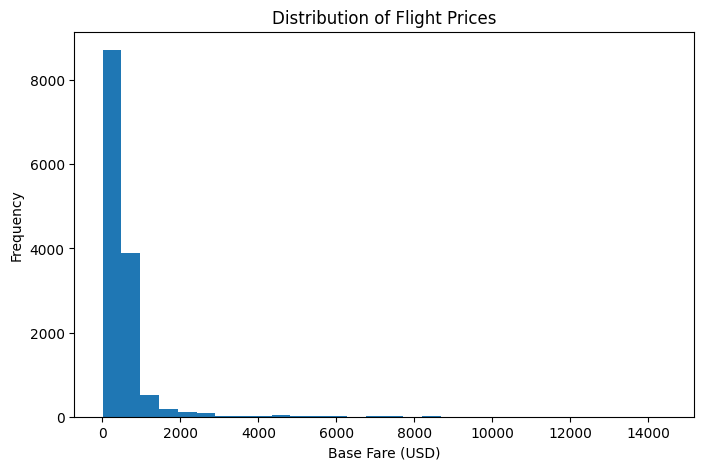

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(flights["base_fare_usd"], bins=30)
plt.title("Distribution of Flight Prices")
plt.xlabel("Base Fare (USD)")
plt.ylabel("Frequency")
plt.show()

Die Flugpreise sind stark rechtsschief verteilt. Die Mehrheit der Buchungen liegt im niedrigen bis mittleren Preisbereich, während nur wenige sehr teure Flüge vorkommen. Diese hochpreisigen Flüge erhöhen den Durchschnittspreis deutlich über den Median.

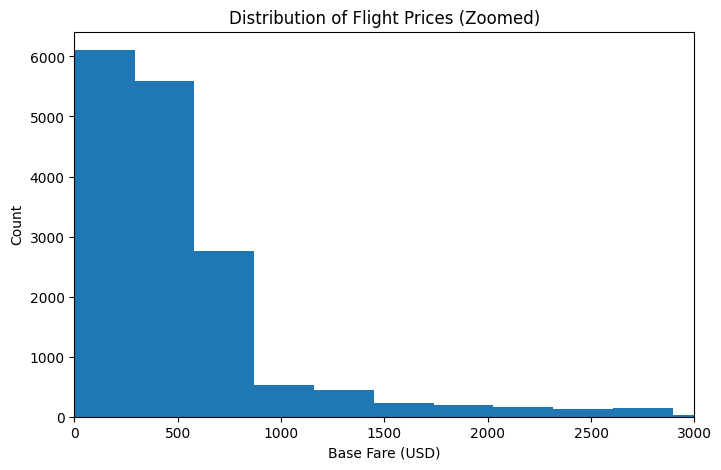

In [81]:
plt.figure(figsize=(8,5))

plt.hist(
    flights["base_fare_usd"],
    bins=50
)

plt.xlim(0, 3000)

plt.title("Distribution of Flight Prices (Zoomed)")
plt.xlabel("Base Fare (USD)")
plt.ylabel("Count")

plt.show()

In [58]:
flights["total_revenue"] = flights["seats"]*flights["base_fare_usd"]

In [59]:
flights[ ["base_fare_usd", "seats", "checked_bags"]].corr(numeric_only=True)

,base_fare_usd,seats,checked_bags
base_fare_usd,1.000000,0.544444,0.287713
seats,0.544444,1.000000,0.295607
checked_bags,0.287713,0.295607,1.000000


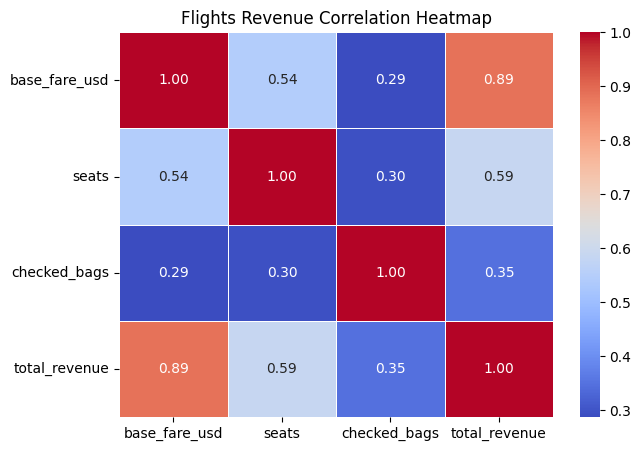

In [62]:
corr_matrix = flights[ ["base_fare_usd", "seats", "checked_bags", "total_revenue"]
].corr(numeric_only=True)

plt.figure(figsize=(7,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Flights Revenue Correlation Heatmap")
plt.show()

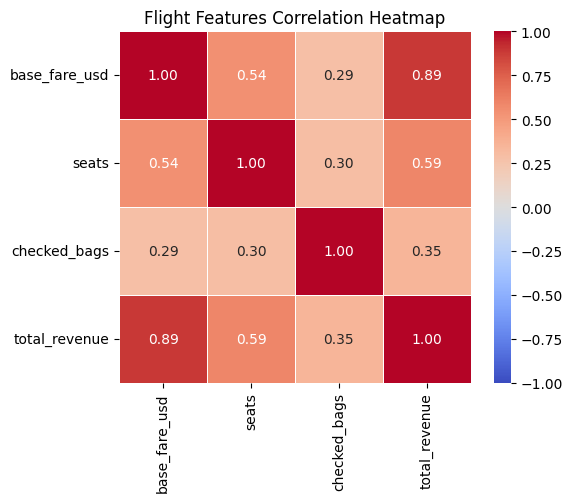

In [63]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Flight Features Correlation Heatmap")
plt.tight_layout()
plt.show()

Die stärkste Korrelation zum Flugumsatz zeigt der Ticketpreis (base_fare_usd, r = 0.89), gefolgt von der Anzahl der gebuchten Sitzplätze (seats, r = 0.62). Die Anzahl aufgegebener Gepäckstücke (checked_bags, r = 0.43) weist einen moderaten Zusammenhang auf. Der Ticketpreis ist somit der wichtigste Treiber des Flugumsatzes.

In [71]:
session_flight_discount = sessions[["trip_id", "flight_discount_amount"]]

In [72]:
session_flight_discount.loc[:, "flight_discount_amount"] = 1 - session_flight_discount["flight_discount_amount"].fillna(0)

In [73]:
flights = flights.merge(session_flight_discount, on="trip_id", how="left")

In [67]:
flights.columns

Index(['trip_id', 'origin_airport', 'destination', 'destination_airport',
       'seats', 'return_flight_booked', 'departure_time', 'return_time',
       'checked_bags', 'trip_airline', 'destination_airport_lat',
       'destination_airport_lon', 'base_fare_usd', 'user_id', 'total_revenue',
       'flight_discount_amount'],
      dtype='object')

In [74]:
flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id,total_revenue,flight_discount_amount_x,flight_discount_amount_y
0,363535-ae2567b185da4e3994607ce71f98a96b,CLT,phoenix,PHX,1,False,2023-01-13 15:00:00.000000,NaN,0,Alaska Airlines,33.535,-112.383,251.87,363535,251.87,1.0,1.0
1,549482-f5e7931dd7b6460b90b89ea0aaabfc78,YVR,san diego,SAN,1,True,2023-07-25 11:00:00.000000,2023-07-31 11:00:00.000000,1,American Airlines,32.699,-117.215,369.26,549482,369.26,1.0,1.0
2,585745-7f13ca3cb64441e08ba34a3020e7ff7b,LBB,new york,JFK,1,True,2023-07-24 07:00:00.000000,2023-07-29 07:00:00.000000,0,Allegiant Air,40.640,-73.779,407.51,585745,407.51,1.0,1.0
3,596153-eb736cf7fe6f4aaf8c1638e399111ced,YKZ,calgary,YYC,1,True,2023-07-25 15:00:00.000000,2023-07-27 15:00:00.000000,1,WestJet,51.114,-114.020,449.58,596153,449.58,1.0,1.0
4,636526-80cabddfe58c406d9ba90c77f85c66ff,LGA,los angeles,LAX,1,True,2023-07-23 13:00:00.000000,2023-07-26 13:00:00.000000,1,Air New Zealand,33.942,-118.408,691.85,636526,691.85,0.9,0.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16933,544449-e96a99d225be4ca2862bfa16d02f94d9,LGA,chicago,MDW,2,True,2023-03-30 08:00:00.000000,2023-04-01 08:00:00.000000,0,AirTran Airways,41.786,-87.752,389.69,544449,779.38,0.9,0.9
16934,566735-978b549aa0804742883e1a10e57d6790,BOS,indianapolis,IND,1,True,2023-04-02 09:00:00.000000,2023-04-06 09:00:00.000000,1,Allegiant Air,39.717,-86.294,175.15,566735,175.15,1.0,1.0
16935,580611-b8fc699133a8430a935067cd85f68549,JFK,montreal,YUL,1,True,2023-03-31 11:00:00.000000,2023-04-05 11:00:00.000000,0,Royal Jordanian,45.517,-73.417,97.40,580611,97.40,1.0,1.0
16936,588386-233db0f627cf4aaaaeaa9a632daa5ec4,CLE,philadelphia,PHL,1,True,2023-04-04 08:00:00.000000,2023-04-06 08:00:00.000000,2,American Airlines,39.872,-75.241,106.00,588386,106.00,1.0,1.0


In [68]:
flights['total_revenue'].describe()

,total_revenue
count,14798.000000
mean,1093.563116
std,4332.287502
min,2.410000
25%,210.787500
50%,404.165000
75%,660.912500
max,103480.480000


Der Mittelwert ist deutlich größer als der Median. Es gibt einige sehr teure Flüge, die den Durchschnitt stark nach oben ziehen.

Vergleich von correlationen für Hotels

- nights             0.65
- hotel_per_room_usd 0.42
- rooms              0.31

mit Flights

- base_fare_usd      0.89
- seats              0.62
- checked_bags       0.43

Fazit:
 - Bei Hotels ist die Aufenthaltsdauer der wichtigste Umsatztreiber.
 - Bei Flügen ist der Ticketpreis der wichtigste Umsatztreiber.

In [76]:
flights.sort_values("base_fare_usd", ascending=False)[["origin_airport", "destination", "seats", "base_fare_usd"]].head(10)

,origin_airport,destination,seats,base_fare_usd
2461,LSV,colombo,5,14466.33
2460,LSV,colombo,5,14466.33
2459,LSV,colombo,5,14466.33
2458,LSV,colombo,5,14466.33
2462,LSV,colombo,5,14466.33
2455,LSV,colombo,5,14466.33
2456,LSV,colombo,5,14466.33
2457,LSV,colombo,5,14466.33
7618,RIC,shenzhen,6,14280.38
7623,RIC,shenzhen,6,14280.38


Was fällt auf?
- Alle Top-10-Einträge sind dieselbe Verbindung.
- Alle haben 5 Sitze (Maximum).
- Alle haben exakt denselben Preis.

Fazit: Das sieht eher nach einem Premium-/Langstreckenflug oder nach synthetisch generierten Daten aus.

In [78]:
flights[flights["base_fare_usd"] == flights["base_fare_usd"].max()].shape

(8, 17)

In [80]:
flights[flights["base_fare_usd"] == flights["base_fare_usd"].max()][["trip_id", "origin_airport", "destination", "seats"]]

,trip_id,origin_airport,destination,seats
2455,552172-db335472fbf64f48b55a7c7c57bd30c2,LSV,colombo,5
2456,552172-db335472fbf64f48b55a7c7c57bd30c2,LSV,colombo,5
2457,552172-db335472fbf64f48b55a7c7c57bd30c2,LSV,colombo,5
2458,552172-db335472fbf64f48b55a7c7c57bd30c2,LSV,colombo,5
2459,552172-db335472fbf64f48b55a7c7c57bd30c2,LSV,colombo,5
2460,552172-db335472fbf64f48b55a7c7c57bd30c2,LSV,colombo,5
2461,552172-db335472fbf64f48b55a7c7c57bd30c2,LSV,colombo,5
2462,552172-db335472fbf64f48b55a7c7c57bd30c2,LSV,colombo,5


In [82]:
flights.groupby("destination")["base_fare_usd"]\
       .mean()\
       .sort_values(ascending=False)\
       .head(10)

,base_fare_usd
destination,
colombo,14466.330000
phuket,9483.035000
durban,8319.990000
ho chi minh city,7957.960000
agra,7830.395000
casablanca,7793.397778
bangalore,7274.800000
jakarta,6887.240000
delhi,6661.739444


In [83]:
flights[flights["base_fare_usd"] == flights["base_fare_usd"].max()]["trip_id"].nunique()

1

In [93]:
flights.columns

Index(['trip_id', 'origin_airport', 'destination', 'destination_airport',
       'seats', 'return_flight_booked', 'departure_time', 'return_time',
       'checked_bags', 'trip_airline', 'destination_airport_lat',
       'destination_airport_lon', 'base_fare_usd', 'user_id', 'total_revenue',
       'flight_discount_amount'],
      dtype='object')

In [94]:
flights["total_revenue_w_discount"] = flights["total_revenue"]*flights["flight_discount_amount"]

In [95]:
flight_revenue_feature = flights[flights["trip_id"].isin(valid_trip_ids)].groupby("user_id")["total_revenue_w_discount"].sum()  # Feature

In [96]:
flight_revenue_feature = flight_revenue_feature.rename("flight_revenue_w_discount")

In [97]:
session_flight_discount["flight_discount_amount"].value_counts().sort_index()

,count
flight_discount_amount,
0.40,3
0.45,3
0.50,20
0.55,47
0.60,78
0.65,156
0.70,328
0.75,581
0.80,956


In [98]:
flights[[
    "base_fare_usd",
    "seats",
    "flight_discount_amount",
    "total_revenue",
    "total_revenue_w_discount"
]].head(20)

,base_fare_usd,seats,flight_discount_amount,total_revenue,total_revenue_w_discount
0,251.87,1,1.0,251.87,251.870
1,369.26,1,1.0,369.26,369.260
2,407.51,1,1.0,407.51,407.510
3,449.58,1,1.0,449.58,449.580
4,691.85,1,0.9,691.85,622.665
5,224.22,1,1.0,224.22,224.220
6,224.22,1,1.0,224.22,224.220
7,224.22,1,1.0,224.22,224.220
8,224.22,1,1.0,224.22,224.220
9,224.22,1,1.0,224.22,224.220


##Average rooms

In [99]:
user_trip_id = sessions[["user_id", "trip_id"]].drop_duplicates().copy()

hotels = hotels.merge(user_trip_id, on="trip_id", how="left")

In [104]:
hotels.columns


Index(['trip_id', 'hotel_name', 'nights', 'rooms', 'check_in_time',
       'check_out_time', 'hotel_per_room_usd', 'city', 'check_in_year',
       'check_in_month', 'check_in_day', 'check_in_hour', 'check_out_year',
       'check_out_month', 'check_out_day', 'check_out_hour', 'stay_length',
       'hotel_total_cost', 'calculated_nights', 'total_revenue',
       'hotel_discount_amount', 'total_revenue_w_discount', 'user_id'],
      dtype='object')

In [105]:
average_rooms_feature = hotels[hotels["trip_id"].isin(valid_trip_ids)].groupby("user_id")["rooms"].mean() # Feature

In [106]:
average_rooms_feature.head()

,rooms
user_id,
23557,1.50
94883,1.50
101486,1.50
101961,1.00
118043,1.25


In [107]:
hotels.columns

Index(['trip_id', 'hotel_name', 'nights', 'rooms', 'check_in_time',
       'check_out_time', 'hotel_per_room_usd', 'city', 'check_in_year',
       'check_in_month', 'check_in_day', 'check_in_hour', 'check_out_year',
       'check_out_month', 'check_out_day', 'check_out_hour', 'stay_length',
       'hotel_total_cost', 'calculated_nights', 'total_revenue',
       'hotel_discount_amount', 'total_revenue_w_discount', 'user_id'],
      dtype='object')

##Average Nights

In [108]:
average_nights_feature = hotels[hotels["trip_id"].isin(valid_trip_ids)].groupby("user_id")["nights"].mean() # Feature

In [109]:
average_nights_feature.head()

,nights
user_id,
23557,10.0
94883,1.0
101486,4.0
101961,3.8
118043,5.5


##Baggage

In [110]:
average_bags_feature = flights[flights["trip_id"].isin(valid_trip_ids)].groupby("user_id")["checked_bags"].mean()  # Feature

In [111]:
average_bags_feature.head()

,checked_bags
user_id,
94883,0.500000
101486,0.000000
101961,0.400000
118043,1.000000
125845,0.666667


##Cancellation

In [112]:
cancellation_feature = sessions.groupby("user_id")["cancellation"].sum()  # Feature

In [113]:
cancellation_feature

,cancellation
user_id,
23557,0
94883,0
101486,0
101961,0
106907,1
...,...
792549,0
796032,1
801660,0


##Hin-Rückflug

In [114]:
flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd,user_id,total_revenue,flight_discount_amount,total_revenue_w_discount
0,363535-ae2567b185da4e3994607ce71f98a96b,CLT,phoenix,PHX,1,False,2023-01-13 15:00:00.000000,NaN,0,Alaska Airlines,33.535,-112.383,251.87,363535,251.87,1.0,251.870
1,549482-f5e7931dd7b6460b90b89ea0aaabfc78,YVR,san diego,SAN,1,True,2023-07-25 11:00:00.000000,2023-07-31 11:00:00.000000,1,American Airlines,32.699,-117.215,369.26,549482,369.26,1.0,369.260
2,585745-7f13ca3cb64441e08ba34a3020e7ff7b,LBB,new york,JFK,1,True,2023-07-24 07:00:00.000000,2023-07-29 07:00:00.000000,0,Allegiant Air,40.640,-73.779,407.51,585745,407.51,1.0,407.510
3,596153-eb736cf7fe6f4aaf8c1638e399111ced,YKZ,calgary,YYC,1,True,2023-07-25 15:00:00.000000,2023-07-27 15:00:00.000000,1,WestJet,51.114,-114.020,449.58,596153,449.58,1.0,449.580
4,636526-80cabddfe58c406d9ba90c77f85c66ff,LGA,los angeles,LAX,1,True,2023-07-23 13:00:00.000000,2023-07-26 13:00:00.000000,1,Air New Zealand,33.942,-118.408,691.85,636526,691.85,0.9,622.665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16933,544449-e96a99d225be4ca2862bfa16d02f94d9,LGA,chicago,MDW,2,True,2023-03-30 08:00:00.000000,2023-04-01 08:00:00.000000,0,AirTran Airways,41.786,-87.752,389.69,544449,779.38,0.9,701.442
16934,566735-978b549aa0804742883e1a10e57d6790,BOS,indianapolis,IND,1,True,2023-04-02 09:00:00.000000,2023-04-06 09:00:00.000000,1,Allegiant Air,39.717,-86.294,175.15,566735,175.15,1.0,175.150
16935,580611-b8fc699133a8430a935067cd85f68549,JFK,montreal,YUL,1,True,2023-03-31 11:00:00.000000,2023-04-05 11:00:00.000000,0,Royal Jordanian,45.517,-73.417,97.40,580611,97.40,1.0,97.400
16936,588386-233db0f627cf4aaaaeaa9a632daa5ec4,CLE,philadelphia,PHL,1,True,2023-04-04 08:00:00.000000,2023-04-06 08:00:00.000000,2,American Airlines,39.872,-75.241,106.00,588386,106.00,1.0,106.000


In [115]:
flights.groupby("user_id")["return_flight_booked"].sum().value_counts()

,count
return_flight_booked,
2,1266
3,1120
1,1051
4,657
5,244
10,129
8,127
9,122
11,84


In [116]:
flights_unique = flights.drop_duplicates(subset=["trip_id"]).copy()

In [117]:
flights_unique.groupby("user_id")["return_flight_booked"].sum().value_counts()

,count
return_flight_booked,
2,1388
3,1255
1,1177
4,743
5,276
6,75
0,56
7,12
8,2


In [118]:
user_return_flights = ( flights.drop_duplicates("trip_id").groupby("user_id")["return_flight_booked"].sum())

In [119]:
flight_type = user_return_flights.apply(lambda x: "Round Trip" if x > 0 else "One Way")

In [120]:
flight_type.value_counts()

,count
return_flight_booked,
Round Trip,4928
One Way,56


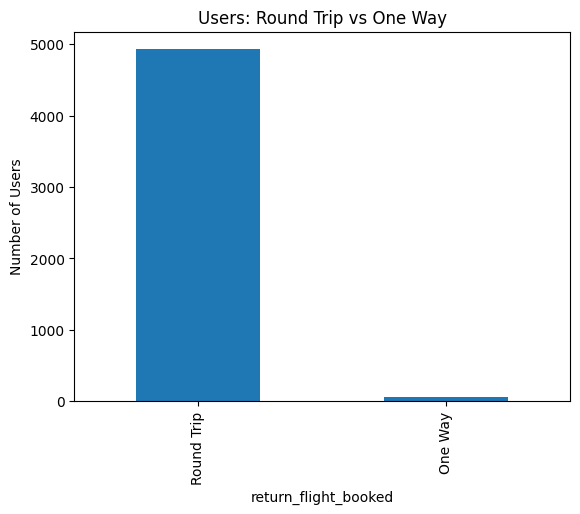

In [121]:

flight_type.value_counts().plot(kind="bar")

plt.title("Users: Round Trip vs One Way")
plt.ylabel("Number of Users")
plt.show()

Die Mehrheit der Nutzer bucht Hin- und Rückflüge. Ein kleinerer Anteil entscheidet sich für einfache Flüge ohne Rückreise. Dies deutet darauf hin, dass die Plattform überwiegend für komplette Reisen genutzt wird.

##Amount Unique Flights

In [122]:
amount_unique_destination_feature = flights[flights["trip_id"].isin(valid_trip_ids)].groupby("user_id")["destination"].nunique() # Feature

In [123]:
amount_unique_destination_feature.rename('amount_unique_destinations', inplace=True)

,amount_unique_destinations
user_id,
94883,2
101486,1
101961,5
118043,3
125845,3
...,...
785186,2
792549,4
796032,2


Die meisten Nutzer reisen nur zu 1–2 verschiedenen Zielen, während einige Nutzer deutlich vielfältiger reisen und mehrere unterschiedliche Destinationen besuchen.

##Favourite Hotel

In [124]:
hotels[["user_id", "hotel_name"]]

,user_id,hotel_name
0,118043,Fairmont
1,204943,Aman Resorts
2,229009,Wyndham
3,229330,Extended Stay
4,283325,Wyndham
...,...,...
15547,680735,Conrad
15548,698573,Conrad
15549,736075,InterContinental
15550,757930,Starwood


In [125]:
user_hotel_occupancy = pd.crosstab(hotels[hotels["trip_id"].isin(valid_trip_ids)]['user_id'], hotels[hotels["trip_id"].isin(valid_trip_ids)]['hotel_name']).reset_index()

In [126]:
user_hotel_occupancy

hotel_name,user_id,Accor,Aman Resorts,Banyan Tree,Best Western,Choice Hotels,Conrad,Crowne Plaza,Extended Stay,Fairmont,...,Hilton,Hyatt,InterContinental,Marriott,NH Hotel,Radisson,Rosewood,Shangri-La,Starwood,Wyndham
0,23557,0,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
1,94883,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,101486,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,101961,1,0,1,0,0,1,0,1,0,...,0,0,0,0,0,0,1,0,0,0
4,118043,0,1,0,0,0,0,0,0,3,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5331,785186,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
5332,792549,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5333,796032,0,0,0,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
5334,801660,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [127]:
hotel_cols = [col for col in user_hotel_occupancy.columns if col != 'user_id']

In [128]:
hotel_cols

['Accor',
 'Aman Resorts',
 'Banyan Tree ',
 'Best Western',
 'Choice Hotels',
 'Conrad ',
 'Crowne Plaza',
 'Extended Stay ',
 'Fairmont',
 'Four Seasons',
 'Hilton',
 'Hyatt',
 'InterContinental ',
 'Marriott ',
 'NH Hotel ',
 'Radisson ',
 'Rosewood',
 'Shangri-La',
 'Starwood ',
 'Wyndham']

In [129]:
import numpy as np

In [130]:
def get_top_hotel(row):
    # Get the values for hotels only
    values = row[hotel_cols].values

    # Find the maximum value
    max_value = values.max()

    # Condition 1: If max value is 0 or 1, return NaN
    if max_value <= 1:
        return np.nan

    # Condition 2: Count how many columns have the max value
    max_count = (values == max_value).sum()

    # If there's a tie for max (more than 1 hotel with the same max value), return NaN
    if max_count > 1:
        return np.nan

    # Otherwise, return the hotel name (column name) with the max value
    return hotel_cols[values.argmax()]

# Apply the function to each row
user_hotel_occupancy.apply(get_top_hotel, axis=1)

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,Fairmont
...,...
5331,NaN
5332,NaN
5333,NaN
5334,NaN


In [136]:
user_hotel_occupancy.columns

Index(['user_id', 'Accor', 'Aman Resorts', 'Banyan Tree ', 'Best Western',
       'Choice Hotels', 'Conrad ', 'Crowne Plaza', 'Extended Stay ',
       'Fairmont', 'Four Seasons', 'Hilton', 'Hyatt', 'InterContinental ',
       'Marriott ', 'NH Hotel ', 'Radisson ', 'Rosewood', 'Shangri-La',
       'Starwood ', 'Wyndham'],
      dtype='object', name='hotel_name')

In [137]:
user_hotel_occupancy["fav_hotel"] = user_hotel_occupancy.apply(
    get_top_hotel,
    axis=1
)

In [138]:
user_hotel_occupancy["fav_hotel"].notna().sum()

np.int64(652)

In [139]:
user_hotel_occupancy["fav_hotel"].value_counts()

,count
fav_hotel,
Best Western,47
Hilton,45
Marriott,44
Extended Stay,40
Shangri-La,37
Rosewood,36
Wyndham,35
Radisson,33
Choice Hotels,32


In [140]:
user_hotel_occupancy[user_hotel_occupancy["fav_hotel"].notna()][["user_id", "fav_hotel"]].head(10)

hotel_name,user_id,fav_hotel
4,118043,Fairmont
6,125845,Four Seasons
14,181157,Radisson
17,190866,Fairmont
29,229330,Extended Stay
38,297546,Rosewood
59,354050,Accor
66,359080,Wyndham
72,372970,Rosewood
95,387783,Starwood


In [141]:
user_hotel_occupancy["fav_hotel"] = user_hotel_occupancy.apply(get_top_hotel, axis=1)

In [142]:
favourite_hotel_feature = user_hotel_occupancy[["user_id", "fav_hotel"]] # Feature

Das Feature favorite_hotel wird nur dann vergeben, wenn ein Nutzer ein Hotel häufiger als einmal gebucht hat und dieses Hotel eindeutig häufiger gebucht wurde als alle anderen Hotels. Bei nur einer Buchung oder bei Gleichstand mehrerer Hotels wird kein Lieblingshotel (NaN) zugewiesen.

#Creating final user_feature table

In [143]:
user_features = (
    user_features
    .merge(amount_only_flights_feature, on="user_id", how="left")
    .merge(amount_only_hotel_feature, on="user_id", how="left")
    .merge(amount_pauschal_trip_feature, on="user_id", how="left")
    .merge(average_seat_feature, on="user_id", how="left")
    .merge(hotel_revenue_feature, on="user_id", how="left")
    .merge(flight_revenue_feature, on="user_id", how="left")
    .merge(average_rooms_feature, on="user_id", how="left")
    .merge(average_nights_feature, on="user_id", how="left")
    .merge(average_bags_feature, on="user_id", how="left")
    .merge(cancellation_feature, on="user_id", how="left")
    .merge(amount_unique_destination_feature, on="user_id", how="left")
    .merge(favourite_hotel_feature, on="user_id", how="left")
)



In [144]:
user_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5998 entries, 0 to 5997
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     5998 non-null   int64  
 1   gender                      5998 non-null   object 
 2   married                     5998 non-null   bool   
 3   has_children                5998 non-null   bool   
 4   home_country                5998 non-null   object 
 5   home_city                   5998 non-null   object 
 6   home_airport                5998 non-null   object 
 7   age                         5998 non-null   int64  
 8   amount_only_flight_trips    1389 non-null   float64
 9   amount_only_hotel_trips     1960 non-null   float64
 10  amount_pauschal_trips       4859 non-null   float64
 11  seats                       4855 non-null   float64
 12  hotel_revenue_w_discount    5336 non-null   float64
 13  flight_revenue_w_discount   4855 

In [145]:
duplicate_features = [
    "amount_only_flight_trips",
    "amount_only_hotel_trips",
    "amount_pauschal_trips",
    "seats",
    "hotel_revenue_w_discount",
    "flight_revenue_w_discount",
    "rooms",
    "nights",
    "checked_bags",
    "cancellation",
    "amount_unique_destinations",
    "fav_hotel"
]

for col in duplicate_features:
    x_col = col + "_x"
    y_col = col + "_y"

    if x_col in user_features.columns and y_col in user_features.columns:
        user_features[col] = user_features[x_col].fillna(user_features[y_col])
        user_features = user_features.drop(columns=[x_col, y_col])

In [146]:
user_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5998 entries, 0 to 5997
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     5998 non-null   int64  
 1   gender                      5998 non-null   object 
 2   married                     5998 non-null   bool   
 3   has_children                5998 non-null   bool   
 4   home_country                5998 non-null   object 
 5   home_city                   5998 non-null   object 
 6   home_airport                5998 non-null   object 
 7   age                         5998 non-null   int64  
 8   amount_only_flight_trips    1389 non-null   float64
 9   amount_only_hotel_trips     1960 non-null   float64
 10  amount_pauschal_trips       4859 non-null   float64
 11  seats                       4855 non-null   float64
 12  hotel_revenue_w_discount    5336 non-null   float64
 13  flight_revenue_w_discount   4855 

In [147]:
user_features.to_csv(
    "/content/drive/MyDrive/user_features.csv",
    index=False
)


In [148]:
user_features.shape

(5998, 20)